In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('./data/sale.xlsx')

In [6]:
df.columns.values.tolist()

['index',
 'id',
 'price',
 'rooms',
 'square_meters',
 'address',
 'date',
 'source',
 'furniture',
 'renovation',
 'price_per_meter',
 'floor',
 'building_floors',
 'height',
 'bathroom',
 'rent_or_sale',
 'links',
 'y',
 'x',
 'district',
 'closest_metro',
 'walking_distance_to_metro(m)']

## Exploratory data analysis

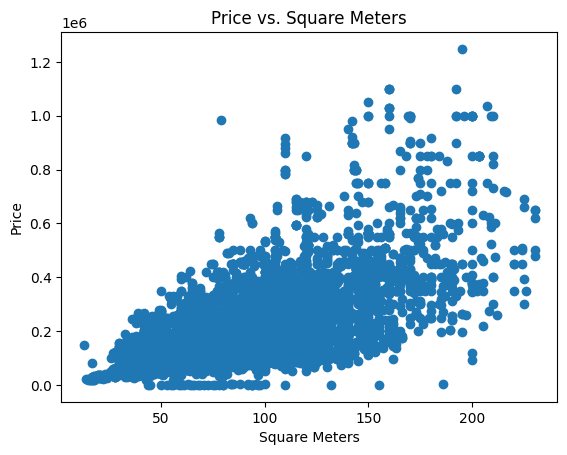

In [7]:
# Scatterplot of price vs. square meters
plt.scatter(df['square_meters'], df['price'])
plt.xlabel('Square Meters')
plt.ylabel('Price')
plt.title('Price vs. Square Meters')
plt.show()

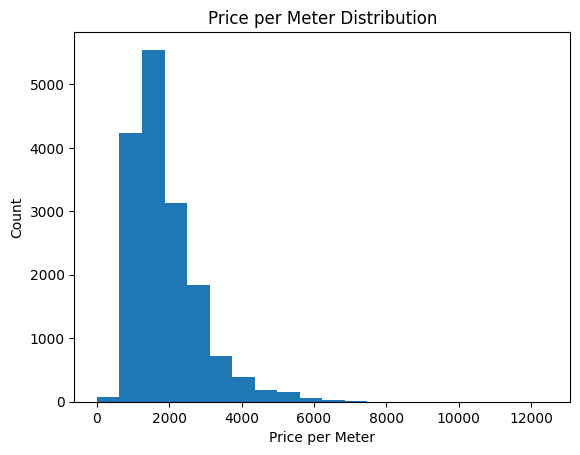

In [8]:
plt.hist(df['price_per_meter'], bins=20)
plt.xlabel('Price per Meter')
plt.ylabel('Count')
plt.title('Price per Meter Distribution')
plt.show()

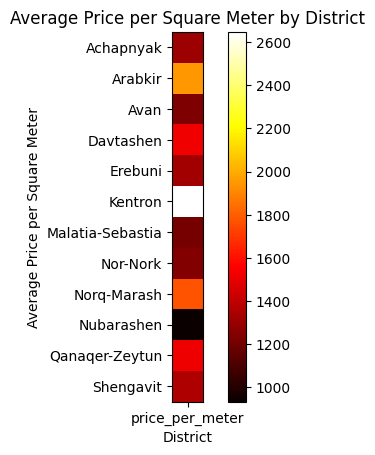

In [9]:
district_prices = df.groupby('district')['price_per_meter'].mean().reset_index()
heatmap_data = pd.pivot_table(district_prices, values='price_per_meter', index='district')
plt.imshow(heatmap_data, cmap='hot', interpolation='nearest')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel('District')
plt.ylabel('Average Price per Square Meter')
plt.colorbar()
plt.title('Average Price per Square Meter by District')
plt.show()

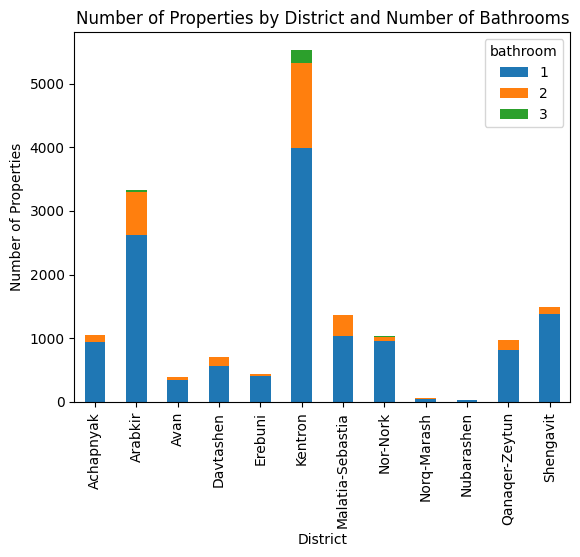

In [14]:
bathroom_counts = df.groupby(['district', 'bathroom']).size().unstack(fill_value=0)
bathroom_counts.plot(kind='bar', stacked=True)
plt.xlabel('District')
plt.ylabel('Number of Properties')
plt.title('Number of Properties by District and Number of Bathrooms')
plt.show()

/var/folders/31/mgjvydd530n_q8xd9pnv0wrc0000gq/T/ipykernel_92906/3611941492.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


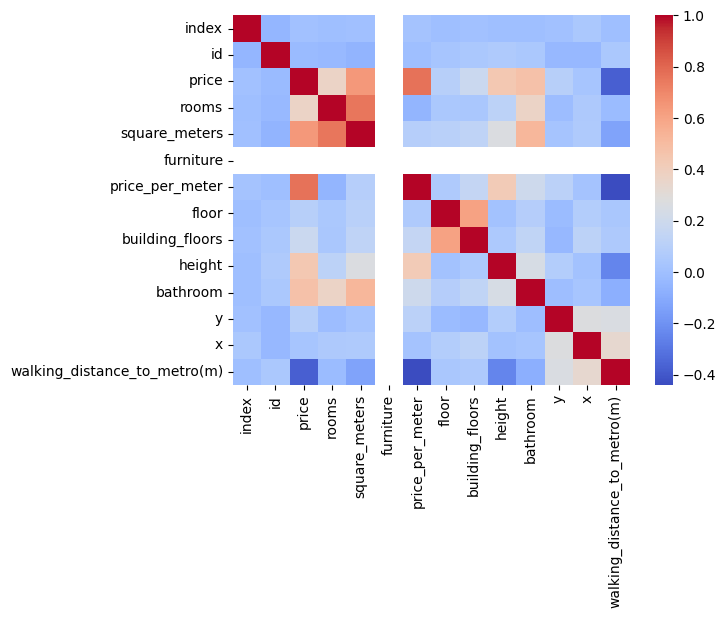

In [15]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.show()

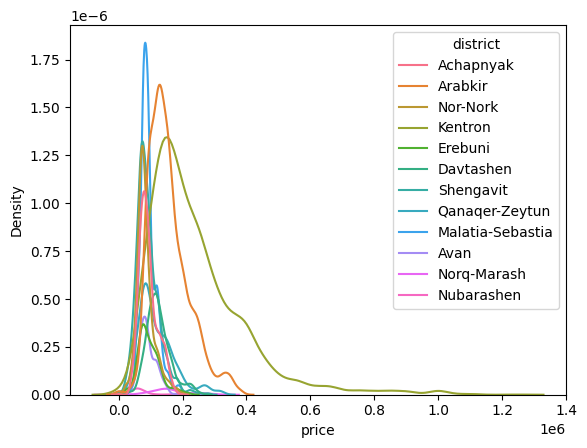

In [16]:
sns.kdeplot(data=df, x="price", hue="district")
plt.show()

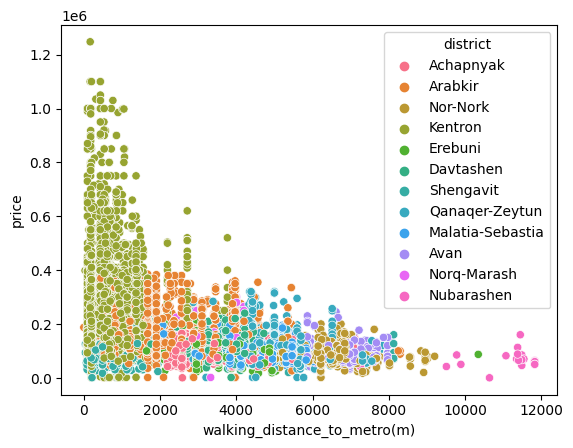

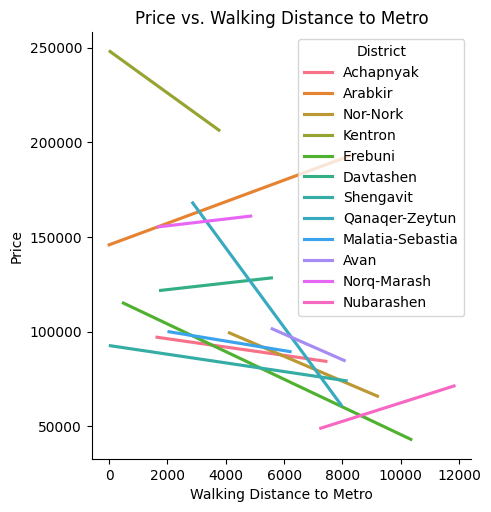

In [25]:
sns.scatterplot(x="walking_distance_to_metro(m)", y="price", hue="district", data=df)
sns.lmplot(x="walking_distance_to_metro(m)", y="price", hue="district", data=df, ci=None, scatter=False, legend=False)
plt.xlabel('Walking Distance to Metro')
plt.ylabel('Price')
plt.title('Price vs. Walking Distance to Metro')
plt.legend(title='District')
plt.show()